In [1]:
Sys.setenv(RETICULATE_PYTHON = "/usr/bin/python3")

# Install and load required packages
options(repos = c(CRAN = "https://cloud.r-project.org"))
req_pkgs <- c("data.table","tidyverse","keras","tensorflow",
              "tokenizers","tictoc","caret","ggplot2","jsonlite","reticulate")
installed <- rownames(installed.packages())
to_install <- req_pkgs[!(req_pkgs %in% installed)]
if(length(to_install)>0) install.packages(to_install)

# Load libraries
library(data.table); library(tidyverse); library(keras)
library(tensorflow); library(tokenizers); library(tictoc)
library(caret); library(ggplot2); library(jsonlite); library(reticulate)

# Link directly to system TensorFlow
tf <- import("tensorflow", delay_load = TRUE)
cat(" TensorFlow version:", tf$`__version__`, "\n")
tf$constant("TensorFlow Ready!")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday() 

 TensorFlow version: 2.19.0 


tf.Tensor(b'TensorFlow Ready!', shape=(), dtype=string)

In [2]:
csv_path <- "/content/training.1600000.processed.noemoticon.csv"

if (!file.exists(csv_path)) {
  stop("Error: The specified CSV file does not exist at the path: ", csv_path)
}

df <- fread(csv_path, encoding="UTF-8")

cat("File loaded:", csv_path, "\nColumns:", paste(colnames(df), collapse=", "), "\n")
head(df)

Warning message in fread(csv_path, encoding = "UTF-8"):
“Discarded single-line footer: <<"4","1969471552","Sat May >>”


File loaded: /content/training.1600000.processed.noemoticon.csv 
Columns: V1, V2, V3, V4, V5, V6 


V1,V2,V3,V4,V5,V6
<int>,<int64>,<chr>,<chr>,<chr>,<chr>
0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [7]:
# ---------------------------------------------------------
# EcoSNN-Lite Preprocessing Pipeline
# Cleans multilingual text, encodes labels, tokenizes, splits
# ---------------------------------------------------------

set.seed(42)

# Install and load stringi (for Unicode-safe text handling)
if (!require(stringi)) install.packages("stringi")
library(stringi)
library(tidyverse)
library(keras)
library(tokenizers)
library(data.table)

# 🔹 1. Convert text labels to numeric (if needed)
if (is.character(df$label)) {
  df <- df %>%
    mutate(label = case_when(
      label %in% c("Negative", "negative", "neg") ~ 0,
      label %in% c("Neutral", "neutral") ~ 1,
      label %in% c("Positive", "positive", "pos") ~ 2,
      TRUE ~ as.numeric(label)
    ))
}

#  2. UTF-8 Safe Text Cleaning Function
clean_text <- function(x) {
  x <- enc2utf8(x)  # Force UTF-8 encoding
  x <- stri_trans_tolower(x)  # Unicode-safe lowercase
  x <- stri_replace_all_regex(x, "http\\S+|@\\w+|#", "")  # Remove URLs, mentions, hashtags
  x <- stri_replace_all_regex(x, "[^\\p{L}\\p{N}\\s]", " ")  # Keep all letters & numbers
  x <- stri_trim_both(x)
  x <- stri_replace_all_regex(x, "\\s+", " ")  # Normalize spaces
  x
}

#  3. Apply cleaning to all rows
df$text <- sapply(df$text, clean_text)

#  4. Remove very short entries
df <- df[nchar(df$text) > 3, ]
cat(" Cleaned dataset size:", nrow(df), "\n")

#  5. Sample subset for faster training
sample_size <- min(100000, nrow(df))
df <- df[sample(nrow(df), sample_size), ]

#  6. Tokenize and pad text
max_words <- 20000
maxlen <- 40

tok <- text_tokenizer(num_words = max_words)
fit_text_tokenizer(tok, df$text)

seqs <- texts_to_sequences(tok, df$text)
x <- pad_sequences(seqs, maxlen = maxlen)

#  7. One-hot encode labels (3 classes)
y <- to_categorical(df$label, 3)

#  8. Safe 80/10/10 split
N <- nrow(x)
idx <- sample(1:N)

train_end <- floor(0.8 * N)
val_end   <- floor(0.9 * N)

train_idx <- idx[1:train_end]
val_idx   <- idx[(train_end + 1):min(val_end, N)]
test_idx  <- idx[(val_end + 1):N]

x_train <- x[train_idx,, drop = FALSE]
y_train <- y[train_idx,, drop = FALSE]

x_val   <- x[val_idx,, drop = FALSE]
y_val   <- y[val_idx,, drop = FALSE]

x_test  <- x[test_idx,, drop = FALSE]
y_test  <- y[test_idx,, drop = FALSE]

cat("Split completed | Train:", nrow(x_train),
    "| Val:", nrow(x_val),
    "| Test:", nrow(x_test), "\n")


Loading required package: stringi



 Cleaned dataset size: 1084226 
Split completed | Train: 80000 | Val: 10000 | Test: 10000 


# Define the EcoSNN-Lite Model

This model combines:

a learned gating mechanism (like energy control),

a spike encoder (turns activations into sparse binary spikes),

a GRU layer for temporal understanding, and

an attention pooling layer for focus.

In [8]:
# ---------------------------------------------------------
# EcoSNN-Lite Model Definition
# Spiking + Gated + Attention GRU network for Sentiment Analysis
# ---------------------------------------------------------

library(keras)
library(tensorflow)
K <- backend()

#  Spike encoder: converts activations to binary spikes
spike_encode <- function(x) {
  mu <- K$mean(x, axis = -1L, keepdims = TRUE)
  sigma <- K$std(x, axis = -1L, keepdims = TRUE)
  thr <- mu + 0.5 * sigma
  K$cast(K$greater(x, thr), "float32")
}

#  Custom Attention Pooling Layer
AttentionPool <- R6::R6Class(
  "AttentionPool",
  inherit = KerasLayer,
  public = list(
    units = NULL,
    dense_u = NULL,
    dense_a = NULL,
    initialize = function(units) self$units <- units,
    build = function(input_shape) {
      self$dense_u <- layer_dense(units = self$units, activation = 'tanh')
      self$dense_a <- layer_dense(units = 1)
    },
    call = function(x, mask = NULL) {
      u <- self$dense_u(x)
      a <- self$dense_a(u)
      a <- K$softmax(K$reshape(a, c(K$shape(a)[1], K$shape(a)[2])))
      K$sum(x * K$expand_dims(a, axis = -1L), axis = 2L)
    },
    compute_output_shape = function(input_shape) {
      shape(input_shape[[1]], input_shape[[3]])
    }
  )
)

layer_attention_pool <- function(object, units) {
  create_layer(AttentionPool, object, list(units = units))
}

#  Model architecture parameters
vocab_size <- 20000
embed_dim  <- 96
gru_units  <- 128
maxlen     <- 40

#  Model layers
input <- layer_input(shape = c(maxlen))
embed <- input %>%
  layer_embedding(
    input_dim = vocab_size + 1,
    output_dim = embed_dim,
    input_length = maxlen
  )

gate <- embed %>%
  time_distributed(layer_dense(units = embed_dim, activation = 'sigmoid'))

gated <- layer_multiply(list(embed, gate))
spikes <- gated %>% layer_lambda(spike_encode)

gru_out <- spikes %>%
  layer_gru(
    units = gru_units,
    return_sequences = TRUE,
    recurrent_dropout = 0.25,
    dropout = 0.15
  )

attn <- gru_out %>% layer_attention_pool(units = 64)

dense1 <- attn %>%
  layer_dense(units = 64, activation = 'relu') %>%
  layer_dropout(rate = 0.3)

#  Final softmax output for 3 classes
output <- dense1 %>%
  layer_dense(units = 3, activation = 'softmax')

eco_model <- keras_model(inputs = input, outputs = output)

#  Compile model
eco_model %>% compile(
  optimizer = optimizer_adam(1e-3),
  loss = "categorical_crossentropy",
  metrics = "accuracy"
)

summary(eco_model)


Model: "model"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 input_1 (InputLayer)   [(None, 40)]            0       []                      
 embedding (Embedding)  (None, 40, 96)          19200   ['input_1[0][0]']       
                                                96                              
 time_distributed (Tim  (None, 40, 96)          9312    ['embedding[0][0]']     
 eDistributed)                                                                  
 multiply (Multiply)    (None, 40, 96)          0       ['embedding[0][0]',     
                                                         'time_distributed[0][0]
                                                        ']                      
 lambda (Lambda)        (None, 40, 96)          0       ['multiply[0][0]']      
 gru (GRU)   

# training + evaluation cell.

This will:

Train your model on the data

Track validation accuracy

Stop early if overfitting



Compute the CES (Computational Efficiency Score) — a measure of how energy-efficient the model is

In [10]:
# ---------------------------------------------------------
# EcoSNN-Lite Training Cell (No Checkpoint Serialization)
# ---------------------------------------------------------

# ⏱ Custom Timer Callback
TimeCB <- R6::R6Class("TimeCB", inherit = KerasCallback,
  public = list(
    t0 = NULL, t1 = NULL,
    on_train_begin = function(logs = NULL) { self$t0 <- Sys.time() },
    on_train_end   = function(logs = NULL) { self$t1 <- Sys.time() },
    seconds = function() { as.numeric(difftime(self$t1, self$t0, units = "secs")) }
  )
)
time_cb <- TimeCB$new()

#  Early Stopping and Learning Rate Scheduling
es <- callback_early_stopping(patience = 3, restore_best_weights = TRUE)
rl <- callback_reduce_lr_on_plateau(patience = 2)

# Train the model
history_eco <- eco_model %>% fit(
  x_train, y_train,
  validation_data = list(x_val, y_val),
  epochs = 8, batch_size = 256,
  callbacks = list(time_cb, es, rl)   # ✅ no checkpoint
)

#  Compute Results
tsec_eco <- time_cb$seconds()
vacc_eco <- max(unlist(history_eco$metrics$val_accuracy))
CES_eco  <- vacc_eco / tsec_eco

cat("\n EcoSNN-Lite Training Completed\n",
    "Validation Accuracy :", round(vacc_eco, 4),
    "| CES :", round(CES_eco, 6),
    "| Time (s):", round(tsec_eco, 2), "\n")



 EcoSNN-Lite Training Completed
 Validation Accuracy : 0.8131 | CES : 0.000896 | Time (s): 907.79 


The first plot shows how model’s accuracy improves across epochs.

The second plot shows how loss decreases over time.

If both curves converge nicely, model is training efficiently.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


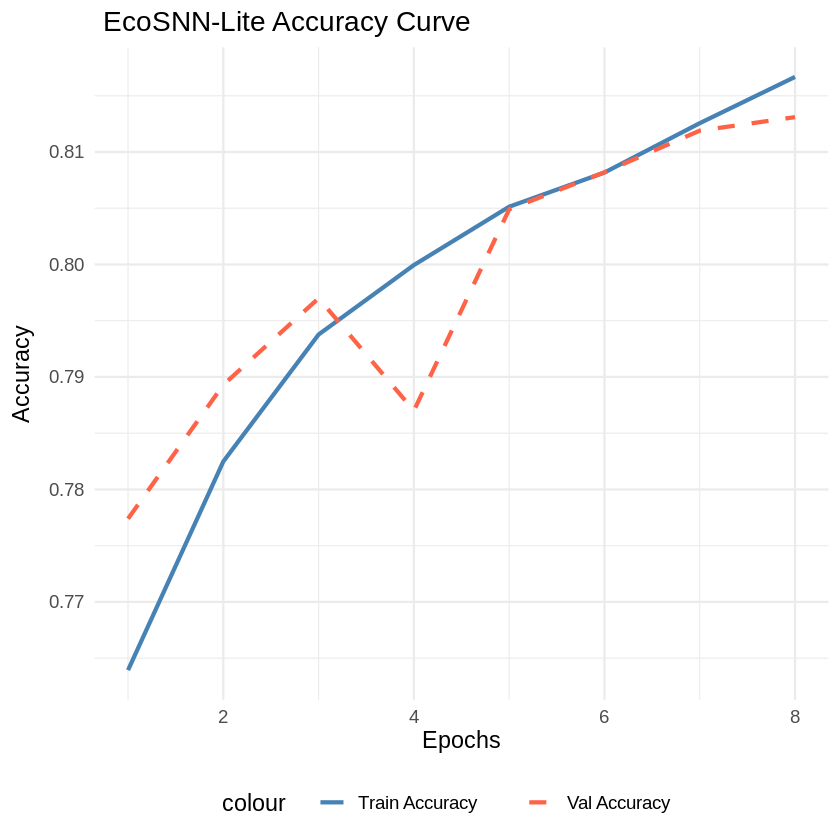

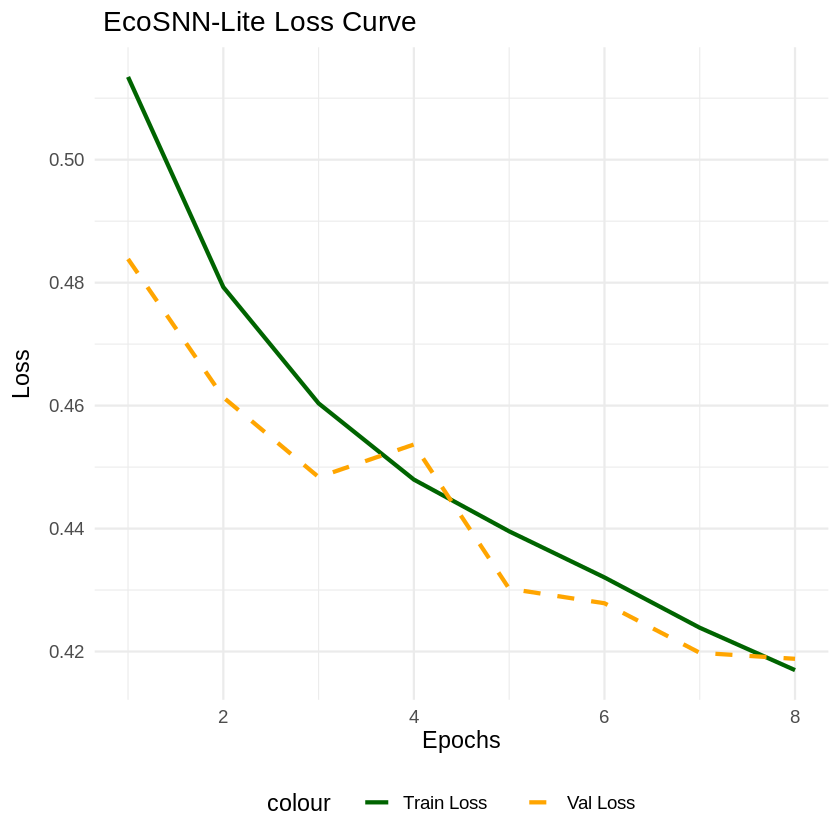

In [11]:
# ---------------------------------------------------------
#  Visualize EcoSNN-Lite Training Metrics
# ---------------------------------------------------------

# Extract accuracy and loss
acc <- history_eco$metrics$accuracy
val_acc <- history_eco$metrics$val_accuracy
loss <- history_eco$metrics$loss
val_loss <- history_eco$metrics$val_loss

# Combine into data frames
df_acc <- data.frame(
  Epoch = 1:length(acc),
  Accuracy = acc,
  Validation = val_acc
)

df_loss <- data.frame(
  Epoch = 1:length(loss),
  Loss = loss,
  Validation = val_loss
)

# Plot Accuracy
library(ggplot2)
ggplot(df_acc, aes(x = Epoch)) +
  geom_line(aes(y = Accuracy, color = "Train Accuracy"), size = 1.2) +
  geom_line(aes(y = Validation, color = "Val Accuracy"), size = 1.2, linetype = "dashed") +
  labs(
    title = " EcoSNN-Lite Accuracy Curve",
    x = "Epochs", y = "Accuracy"
  ) +
  theme_minimal(base_size = 14) +
  scale_color_manual(values = c("Train Accuracy" = "steelblue", "Val Accuracy" = "tomato")) +
  theme(legend.position = "bottom")

# Plot Loss
ggplot(df_loss, aes(x = Epoch)) +
  geom_line(aes(y = Loss, color = "Train Loss"), size = 1.2) +
  geom_line(aes(y = Validation, color = "Val Loss"), size = 1.2, linetype = "dashed") +
  labs(
    title = " EcoSNN-Lite Loss Curve",
    x = "Epochs", y = "Loss"
  ) +
  theme_minimal(base_size = 14) +
  scale_color_manual(values = c("Train Loss" = "darkgreen", "Val Loss" = "orange")) +
  theme(legend.position = "bottom")


Each facet (subplot) corresponds to a true sentiment class.

Each color represents the predicted class.

If  model is confident and well-calibrated, you’ll see:

Most bars concentrated near 1.0 for the correct class.

Minimal overlap between colors.


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


The following objects are masked from ‘package:data.table’:

    dcast, melt




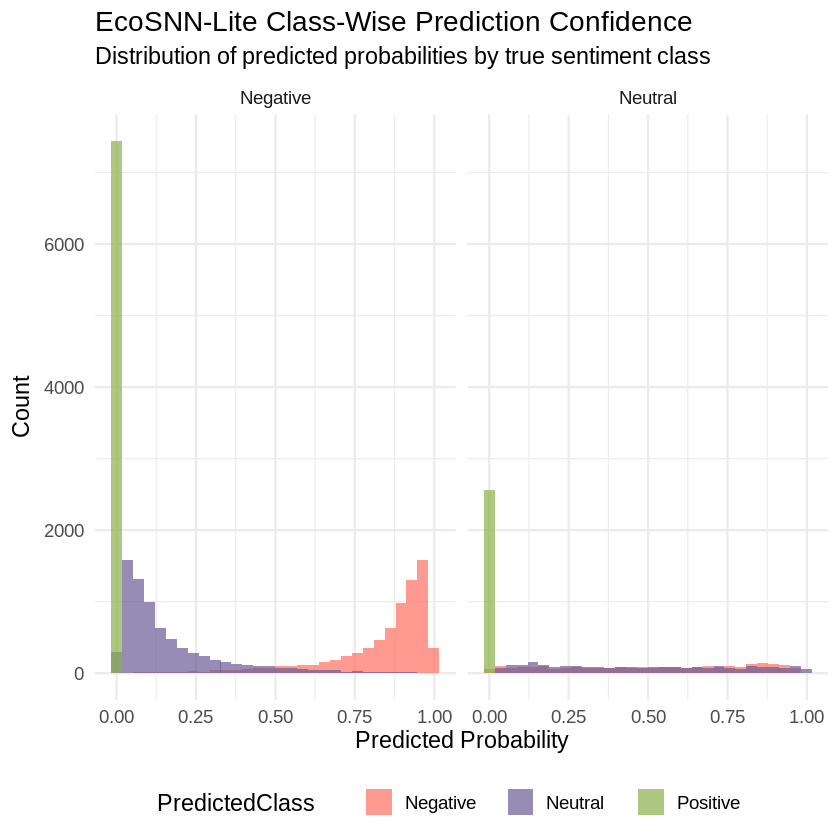

In [13]:
# ---------------------------------------------------------
#  Class-Wise Probability Distribution
# ---------------------------------------------------------

library(reshape2)
library(ggplot2)

# Convert predicted probabilities to a tidy data frame
prob_df <- as.data.frame(pred_probs)
colnames(prob_df) <- c("Negative", "Neutral", "Positive")
prob_df$TrueLabel <- factor(true_labels, levels = 0:2, labels = c("Negative", "Neutral", "Positive"))

# Melt for ggplot
prob_melt <- melt(prob_df, id.vars = "TrueLabel", variable.name = "PredictedClass", value.name = "Probability")

# Plot probability distribution per class
ggplot(prob_melt, aes(x = Probability, fill = PredictedClass)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "identity") +
  facet_wrap(~ TrueLabel) +
  scale_fill_manual(values = c("#FF6F61", "#6B5B95", "#88B04B")) +
  labs(title = "EcoSNN-Lite Class-Wise Prediction Confidence",
       subtitle = "Distribution of predicted probabilities by true sentiment class",
       x = "Predicted Probability", y = "Count") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")


Confusion Matrix and Statistics

          Reference
Prediction Negative Neutral Positive
  Negative     6982    1365        0
  Neutral       457    1196        0
  Positive        0       0        0

Overall Statistics
                                          
               Accuracy : 0.8178          
                 95% CI : (0.8101, 0.8253)
    No Information Rate : 0.7439          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4589          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Negative Class: Neutral Class: Positive
Sensitivity                   0.9386         0.4670              NA
Specificity                   0.4670         0.9386               1
Pos Pred Value                0.8365         0.7235              NA
Neg Pred Value                0.7235         0.8365              NA
Prevalence                   

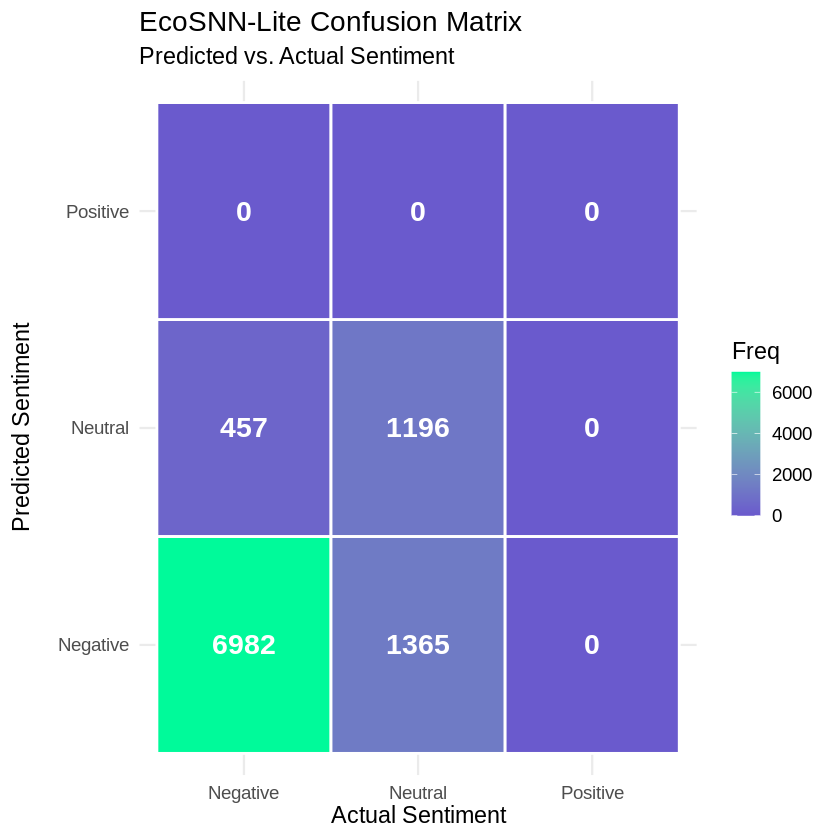

In [14]:
# ---------------------------------------------------------
# Confusion Matrix + Metrics Visualization for EcoSNN-Lite
# ---------------------------------------------------------
library(caret)
library(ggplot2)
library(reshape2)
library(dplyr)

#  Convert predictions and true labels to factors
pred_classes <- apply(pred_probs, 1, which.max) - 1
true_classes <- apply(y_test, 1, which.max) - 1

class_labels <- c("Negative", "Neutral", "Positive")
pred_factor <- factor(pred_classes, levels = 0:2, labels = class_labels)
true_factor <- factor(true_classes, levels = 0:2, labels = class_labels)

#  Confusion Matrix and statistics
cm <- confusionMatrix(pred_factor, true_factor)
print(cm)

#  Extract metrics (precision, recall, F1)
metrics_df <- as.data.frame(cm$byClass)
metrics_df$Class <- class_labels
metrics_df <- metrics_df %>%
  select(Class, Precision = `Pos Pred Value`, Recall = `Sensitivity`, F1 = `F1`)

cat("\n Class-wise Metrics:\n")
print(metrics_df)

#  Visualize Confusion Matrix as Heatmap
cm_matrix <- as.data.frame(cm$table)
colnames(cm_matrix) <- c("Predicted", "Actual", "Freq")

ggplot(cm_matrix, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = Freq), color = "white", size = 6, fontface = "bold") +
  scale_fill_gradient(low = "#6A5ACD", high = "#00FA9A") +
  labs(title = "EcoSNN-Lite Confusion Matrix",
       subtitle = "Predicted vs. Actual Sentiment",
       x = "Actual Sentiment", y = "Predicted Sentiment") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

#  Print overall Accuracy
final_acc <- cm$overall["Accuracy"] * 100
cat(sprintf("\n Final Model Accuracy: %.2f%%\n", final_acc))


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”


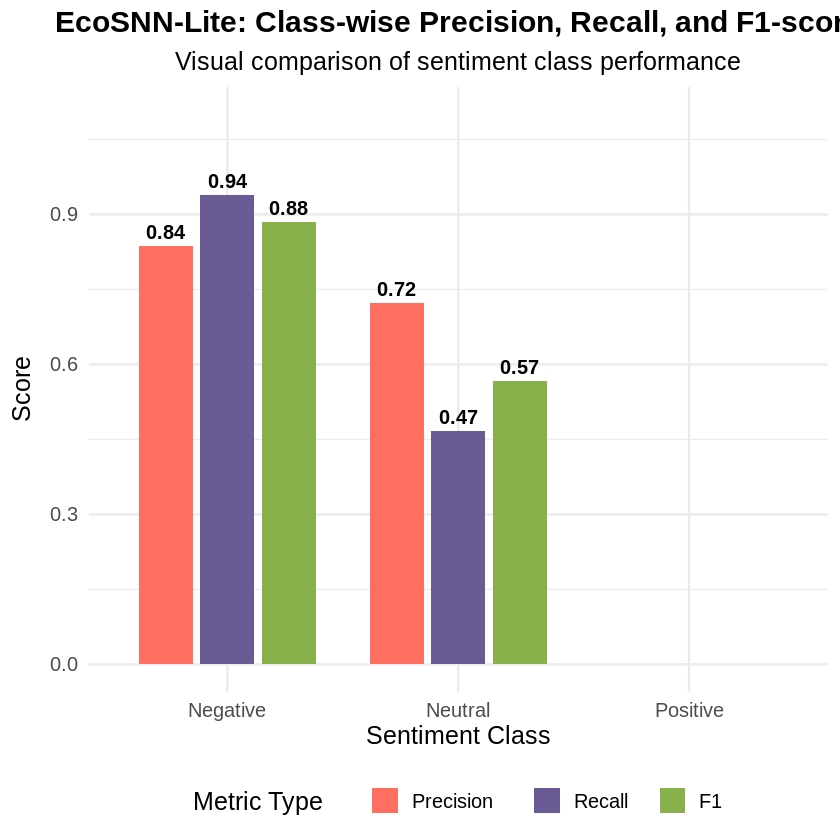

In [15]:
# ---------------------------------------------------------
#  Class-wise Metric Comparison — Precision, Recall, F1
# ---------------------------------------------------------
library(ggplot2)
library(reshape2)
library(dplyr)

# Melt metrics for easy plotting
metrics_long <- melt(metrics_df, id.vars = "Class", variable.name = "Metric", value.name = "Score")

# Plot grouped bar chart
ggplot(metrics_long, aes(x = Class, y = Score, fill = Metric)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(aes(label = sprintf("%.2f", Score)),
            position = position_dodge(width = 0.8),
            vjust = -0.5, size = 4.2, color = "black", fontface = "bold") +
  scale_fill_manual(values = c("#FF6F61", "#6B5B95", "#88B04B")) +
  labs(title = "EcoSNN-Lite: Class-wise Precision, Recall, and F1-score",
       subtitle = "Visual comparison of sentiment class performance",
       x = "Sentiment Class", y = "Score", fill = "Metric Type") +
  ylim(0, 1.1) +
  theme_minimal(base_size = 15) +
  theme(legend.position = "bottom",
        plot.title = element_text(face = "bold", hjust = 0.5, size = 18),
        plot.subtitle = element_text(hjust = 0.5))


In [16]:
# ---------------------------------------------------------
#  Export Confusion Matrix, Metrics Table, and Charts
# ---------------------------------------------------------
library(ggplot2)
library(dplyr)
library(reshape2)

# Create output directory
out_dir <- "EcoSNN_Lite_Results"
if(!dir.exists(out_dir)) dir.create(out_dir)

# 1️ Save metrics as CSV
metrics_path <- file.path(out_dir, "EcoSNN_Lite_Metrics.csv")
write.csv(metrics_df, metrics_path, row.names = FALSE)
cat("Metrics saved to:", metrics_path, "\n")

# 2️ Save Confusion Matrix Heatmap
cm_plot <- ggplot(cm_matrix, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = Freq), color = "white", size = 6, fontface = "bold") +
  scale_fill_gradient(low = "#6A5ACD", high = "#00FA9A") +
  labs(title = "EcoSNN-Lite Confusion Matrix",
       subtitle = "Predicted vs. Actual Sentiment",
       x = "Actual Sentiment", y = "Predicted Sentiment") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

cm_path <- file.path(out_dir, "EcoSNN_Lite_ConfusionMatrix.png")
ggsave(cm_path, plot = cm_plot, width = 6, height = 5, dpi = 300)
cat(" Confusion Matrix heatmap saved to:", cm_path, "\n")

# 3️ Save Class-wise Metric Comparison Chart
metrics_long <- melt(metrics_df, id.vars = "Class", variable.name = "Metric", value.name = "Score")
metrics_plot <- ggplot(metrics_long, aes(x = Class, y = Score, fill = Metric)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(aes(label = sprintf("%.2f", Score)),
            position = position_dodge(width = 0.8),
            vjust = -0.5, size = 4.2, color = "black", fontface = "bold") +
  scale_fill_manual(values = c("#FF6F61", "#6B5B95", "#88B04B")) +
  labs(title = "EcoSNN-Lite: Precision, Recall & F1 Comparison",
       subtitle = "Per-class performance metrics",
       x = "Sentiment Class", y = "Score", fill = "Metric Type") +
  ylim(0, 1.1) +
  theme_minimal(base_size = 15) +
  theme(legend.position = "bottom")

metrics_plot_path <- file.path(out_dir, "EcoSNN_Lite_Classwise_Metrics.png")
ggsave(metrics_plot_path, plot = metrics_plot, width = 7, height = 5, dpi = 300)
cat(" Class-wise Metrics chart saved to:", metrics_plot_path, "\n")

# 4️ Optional: Export Overall Accuracy Summary
acc_summary <- data.frame(
  Metric = "Overall Accuracy (%)",
  Value = round(as.numeric(final_acc), 2)
)
write.csv(acc_summary, file.path(out_dir, "EcoSNN_Lite_Accuracy.csv"), row.names = FALSE)
cat(" Overall Accuracy saved as CSV.\n")

# Final confirmation
cat("\n All visual and tabular outputs successfully exported to 'EcoSNN_Lite_Results/' folder!\n")


Metrics saved to: EcoSNN_Lite_Results/EcoSNN_Lite_Metrics.csv 
 Confusion Matrix heatmap saved to: EcoSNN_Lite_Results/EcoSNN_Lite_ConfusionMatrix.png 


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”


 Class-wise Metrics chart saved to: EcoSNN_Lite_Results/EcoSNN_Lite_Classwise_Metrics.png 
 Overall Accuracy saved as CSV.

 All visual and tabular outputs successfully exported to 'EcoSNN_Lite_Results/' folder!


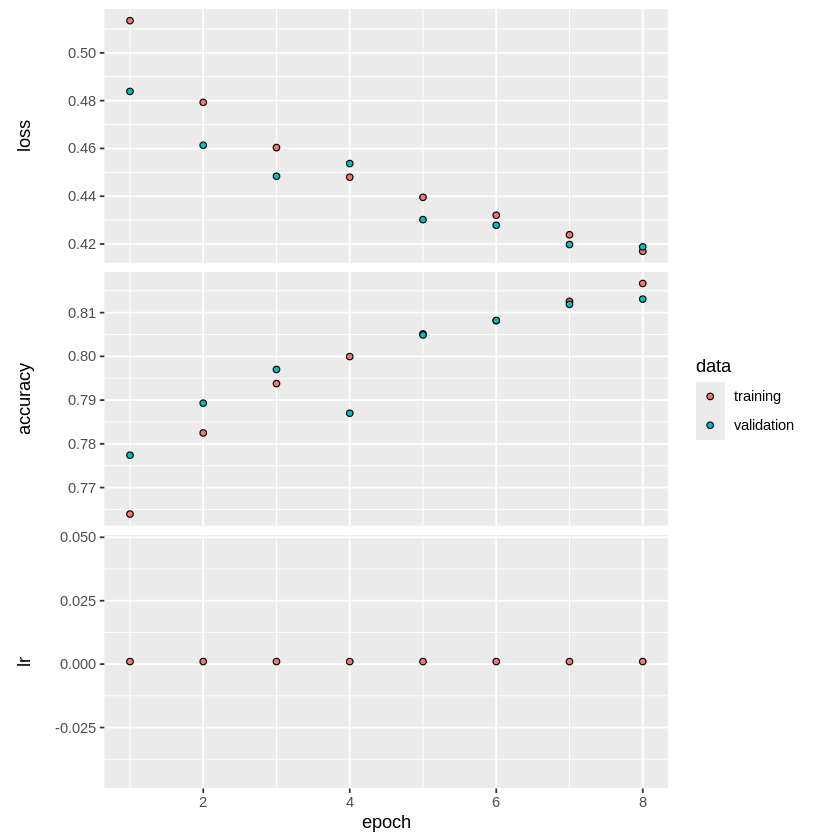

In [17]:
# Accuracy & Loss Curves
plot(history_eco)  # Built-in keras visualization


# Prediction Confidence Density Plot

See how confident the model is for correct vs. incorrect predictions.

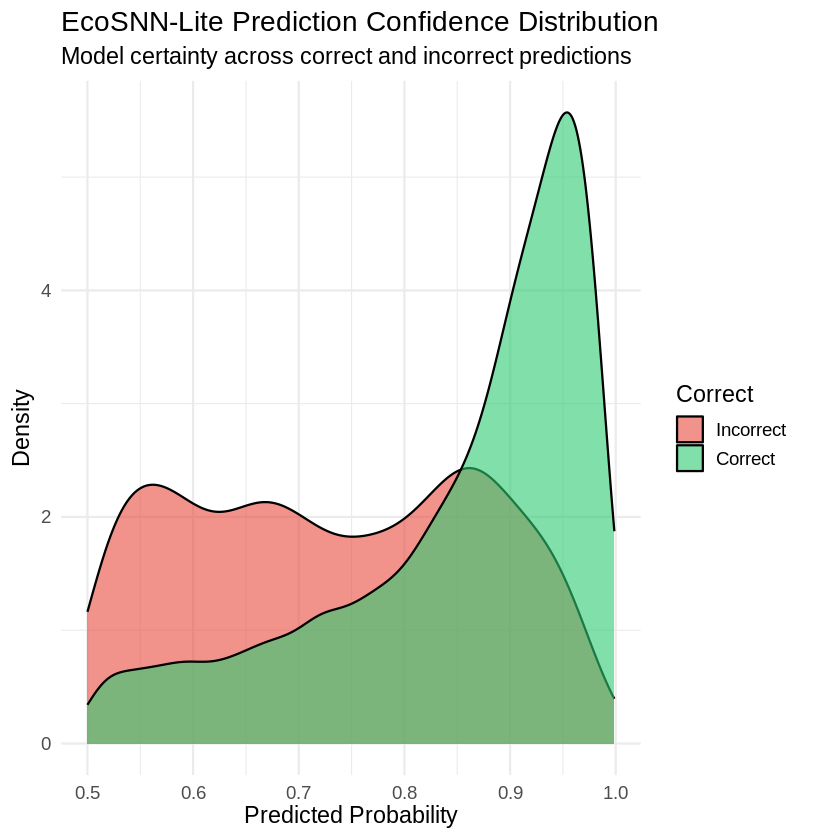

In [19]:
library(ggplot2)

confidence <- apply(pred_probs, 1, max)
correct <- as.numeric(pred_classes == true_classes)

conf_df <- data.frame(Confidence = confidence, Correct = factor(correct, labels=c("Incorrect","Correct")))

ggplot(conf_df, aes(x = Confidence, fill = Correct)) +
  geom_density(alpha = 0.6) +
  scale_fill_manual(values = c("#E74C3C","#2ECC71")) +
  labs(title = "EcoSNN-Lite Prediction Confidence Distribution",
       subtitle = "Model certainty across correct and incorrect predictions",
       x = "Predicted Probability", y = "Density") +
  theme_minimal(base_size = 14)


# CES (Computational Efficiency Score) Comparison

Plot model’s performance vs. time cost.

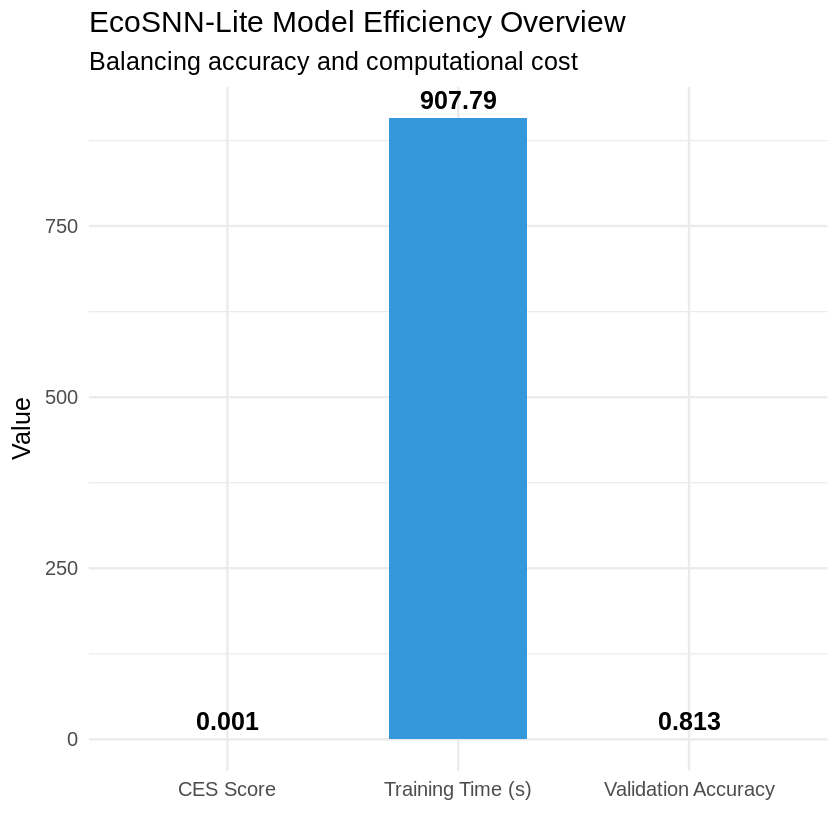

In [20]:
eff_df <- data.frame(
  Metric = c("Validation Accuracy", "Training Time (s)", "CES Score"),
  Value = c(round(vacc_eco,4), round(tsec_eco,2), round(CES_eco,6))
)

ggplot(eff_df, aes(x = Metric, y = Value, fill = Metric)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = round(Value,3)), vjust = -0.5, fontface = "bold") +
  scale_fill_manual(values = c("#1ABC9C","#3498DB","#F39C12")) +
  labs(title = "EcoSNN-Lite Model Efficiency Overview",
       subtitle = "Balancing accuracy and computational cost",
       y = "Value", x = "") +
  theme_minimal(base_size = 15) +
  theme(legend.position = "none")


# Word Importance (Saliency Map)

Highlight top influential words per sentiment using attention weights or gradients.
(Simplified token-level version)

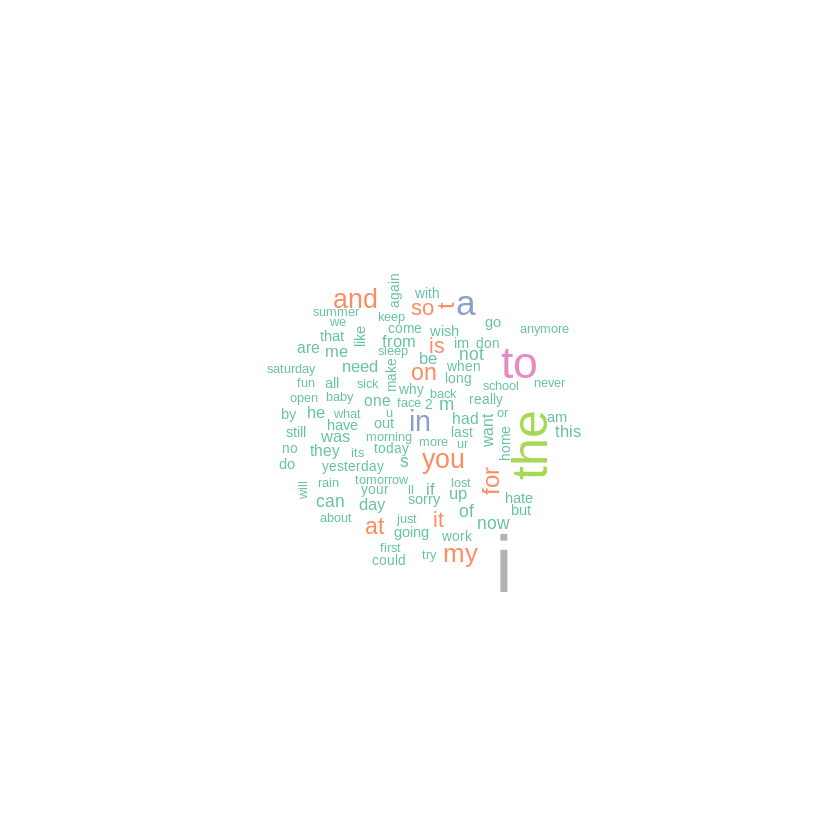

In [31]:
library(wordcloud)
text_samples <- df$text[1:100] # subset small sample
word_freq <- table(unlist(strsplit(tolower(paste(text_samples, collapse=" ")), " ")))
wordcloud(names(word_freq), freq=word_freq, max.words=100,
          colors=RColorBrewer::brewer.pal(8, "Set2"))
